Step 1: Loading data...

Loaded data:
Inputs shape: (30, 4)
Outputs shape: (30,)
Input ranges per dimension (min, max):
  Dim 0: (0.0000, 1.0000)
  Dim 1: (0.0382, 0.9418)
  Dim 2: (0.0889, 1.0000)
  Dim 3: (0.0000, 1.0000)
Output range (min, max): (0.1129, 2781.6545)

First 5 input samples:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]]

First 5 output values:
[6.44434399e+01 1.83013796e+01 1.12939795e-01 4.21089813e+00
 2.58370525e+02]
dimension 4

Step 2: Normalizing data...
Input means: [0.36601525 0.5396188  0.62270701 0.51807309]...
Input stds: [0.27847145 0.30682136 0.29495597 0.34063653]...

Cluster Analysis:
Clusters sizes: [8 7 8 7]
Cluster y-means: [np.float64(139.00527030667467), np.float64(1919.4609217866473), np.float64(416.08904903301175), np.float64(66.30387064940699)]
Inter-centroid 

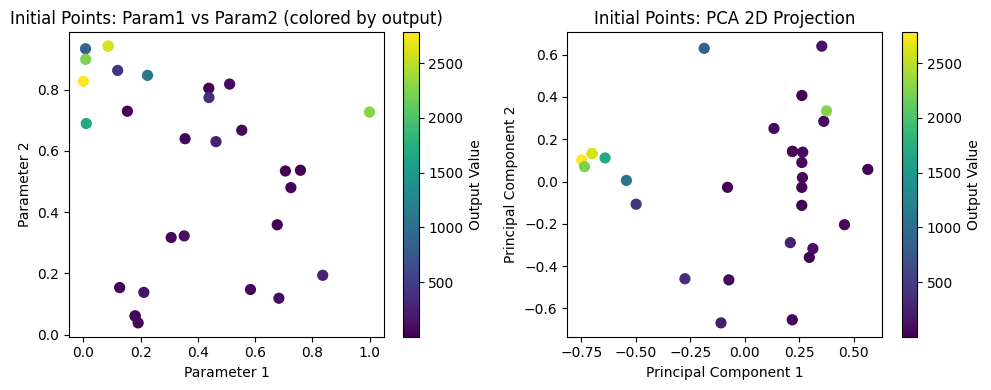

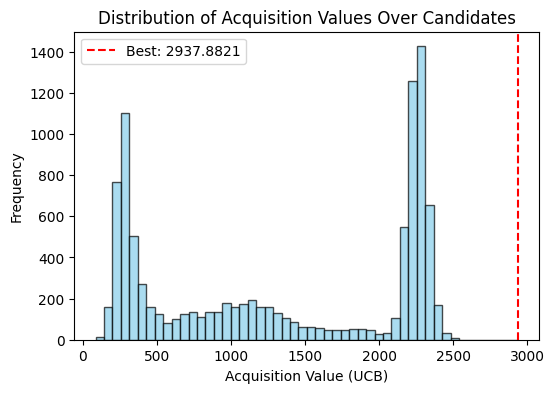

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For potential 3D plots, though we'll use 2D for simplicity
from collections import OrderedDict
import random  # Add if missing
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True  # For GPU consistency
torch.backends.cudnn.benchmark = False
random.seed(42)  # For any Python random (e.g., future splits)


# Step 1: Load the initial data from the provided files
# initial_inputs.npy: Shape (N, 8) where N is the number of initial samples, 8 dimensions
# initial_outputs.npy: Shape (N,) the corresponding output values to maximize (e.g., validation accuracy [0,1])
print("Step 1: Loading data...")
X = np.load('initial_inputs.npy')  # Input parameters
y = np.load('initial_outputs.npy')  # Output values

# ------------------------------------------------------------
# Append new information
# ------------------------------------------------------------
X = np.append(X,[[0.000000, 0.827184, 1.000000, 1.000000]], axis=0)  # Append week1 inputs
y = np.append(y, 2781.6544929246656)                                 # Append week1 outputs
X = np.append(X,[[0.211398, 0.137823, 0.983750, 0.002747]], axis=0)  # Append week2 inputs
y = np.append(y, 149.63607524528655)                                 # Append week2 outputs
X = np.append(X,[[1.000000, 0.726425, 1.000000, 0.000000]], axis=0)  # Append week3 inputs
y = np.append(y, 2279.0650325770825)                                 # Append week3 outputs
X = np.append(X,[[0.180950, 0.059824, 0.636316, 0.447551]], axis=0)  # Append week4 inputs
y = np.append(y, 48.93659903572626)                                  # Append week4 outputs
X = np.append(X,[[0.180844, 0.061249, 0.635744, 0.447044]], axis=0)  # Append week5 inputs
y = np.append(y, 49.227543834062324)                                 # Append week5 outputs
X = np.append(X,[[0.010090, 0.689157, 0.980540, 0.965626]], axis=0)  # Append week6 inputs
y = np.append(y, 1678.5450025639036)                                 # Append week6 outputs
X = np.append(X,[[0.086866, 0.941786, 0.999891, 0.886433]], axis=0)  # Append week7 inputs
y = np.append(y, 2610.1866367387074)                                 # Append week7 outputs
X = np.append(X,[[0.007504, 0.933383, 0.955079, 0.050958]], axis=0)  # Append week8 inputs
y = np.append(y, 873.051259946407)                                   # Append week8 outputs
X = np.append(X,[[0.086866, 0.941786, 0.999891, 0.886433]], axis=0)  # Append week9 inputs
y = np.append(y, 2610.1866367387074)                                 # Append week9 outputs
X = np.append(X,[[0.008198, 0.898815, 0.931120, 0.961021]], axis=0)  # Append week10 inputs
y = np.append(y, 2235.181308585064)                                 # Append week10 outputs


# Print initial data for easy understanding
print("\nLoaded data:")
print(f"Inputs shape: {X.shape}")
print(f"Outputs shape: {y.shape}")
print(f"Input ranges per dimension (min, max):")
for i in range(X.shape[1]):
    print(f"  Dim {i}: ({np.min(X[:, i]):.4f}, {np.max(X[:, i]):.4f})")
print(f"Output range (min, max): ({np.min(y):.4f}, {np.max(y):.4f})")
print("\nFirst 5 input samples:")
print(X[:5])
print("\nFirst 5 output values:")
print(y[:5])

# Assume the parameter space is bounded by the min/max of initial data or [0,1] if applicable.
# For generating new candidates, we'll use [0,1] per dimension for simplicity (common for normalized hyperparameters).
# If your params have different bounds, adjust the uniform sampling below.
dimension = X.shape[1]
print ("dimension", dimension)
bounds = [(0.0, 1.0)] * dimension  # Assuming [0,1] space for all dimensions

# Step 2: Normalize the data for model fitting
# Normalization helps the neural network train stably, especially in high dimensions.
# We use standardization (mean=0, std=1) for inputs.
# For outputs, we also standardize to improve regression stability.
print("\nStep 2: Normalizing data...")

# Input normalization
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0) + 1e-8  # Avoid division by zero
X_norm = (X - X_mean) / X_std

# Output normalization (since we're maximizing, but scaling helps NN)
y_mean = np.mean(y)
y_std = np.std(y) + 1e-8
y_norm = (y - y_mean) / y_std

print(f"Input means: {X_mean[:5]}...")  # Print first few for inspection
print(f"Input stds: {X_std[:5]}...")

# After Step 2 (normalization), add clustering
print("\nCluster Analysis:")
k = 4  # Tune via elbow/silhouette if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)  # On raw X for geometry
centroids = kmeans.cluster_centers_
dist_matrix = pairwise_distances(centroids)  # Inter-cluster distances

# Stats
cluster_y_means = [y[cluster_labels == i].mean() for i in range(k)]
best_cluster = np.argmax(cluster_y_means)
print(f"Clusters sizes: {np.bincount(cluster_labels)}")
print(f"Cluster y-means: {cluster_y_means}")
print(f"Inter-centroid dists:\n{dist_matrix}")
print(f"Best cluster: {best_cluster} (y_mean={cluster_y_means[best_cluster]:.4f})")

from sklearn.model_selection import train_test_split
import itertools  # For generating random combos

# Step 3: Define the Surrogate Neural Network Model using PyTorch
# This NN acts as the surrogate function in Bayesian Optimization.
# We include dropout layers to enable Monte Carlo Dropout for uncertainty estimation.
# Architecture: Input (dimension) -> Hidden (50, ReLU + Dropout) -> Hidden (50, ReLU + Dropout) -> Output (1)
class SurrogateNN(nn.Module):
    def __init__(self, input_dim=dimension, hidden_dim=50, dropout_rate=0.2):
        super(SurrogateNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# ------------------------------------------------------------
# 2. Helper: pretty-print the model architecture
# ------------------------------------------------------------
def print_model_architecture(model: nn.Module, indent: int = 2) -> None:
    """Recursively walk through the module and print layer names + shapes."""
    def _format_module(mod, name, level):
        spaces = " " * (indent * level)
        if isinstance(mod, (nn.Linear, nn.Conv2d, nn.BatchNorm1d, nn.BatchNorm2d)):
            # Linear / Conv layers have a weight tensor
            weight_shape = tuple(mod.weight.shape) if hasattr(mod, "weight") else "-"
            bias_shape   = tuple(mod.bias.shape)   if hasattr(mod, "bias")   else "-"
            print(f"{spaces}{name}: {mod.__class__.__name__}")
            print(f"{spaces}  in/out: {mod.in_features if hasattr(mod,'in_features') else mod.in_channels} → "
                  f"{mod.out_features if hasattr(mod,'out_features') else mod.out_channels}")
            print(f"{spaces}  weight: {weight_shape}, bias: {bias_shape}")
        elif isinstance(mod, (nn.ReLU, nn.Dropout, nn.Sigmoid)):
            print(f"{spaces}{name}: {mod.__class__.__name__}(p={mod.p if hasattr(mod,'p') else '-'})")
        else:
            print(f"{spaces}{name}: {mod.__class__.__name__}")

    print("\n=== Model Architecture ===")
    for name, module in model.named_children():
        _format_module(module, name, level=1)
        # If the module itself contains children, recurse
        if len(list(module.children())) > 0:
            for sub_name, sub_module in module.named_children():
                _format_module(sub_module, f"{name}.{sub_name}", level=2)
    print("="*30 + "\n")


# ------------------------------------------------------------
# 3. Helper: count parameters + memory
# ------------------------------------------------------------
def print_parameter_summary(model: nn.Module) -> None:
    """Print total trainable / non-trainable params and memory usage."""
    total_params   = sum(p.numel() for p in model.parameters())
    trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable  = total_params - trainable

    # Rough memory estimate (float32 = 4 bytes)
    mem_bytes = total_params * 4
    mem_mb    = mem_bytes / (1024 ** 2)

    print("=== Parameter Summary ===")
    print(f"{'Trainable':<15}: {trainable:,}")
    print(f"{'Non-trainable':<15}: {non_trainable:,}")
    print(f"{'Total':<15}: {total_params:,}")
    print(f"{'Memory (FP32)':<15}: {mem_mb:.2f} MiB")
    print("="*30 + "\n")


# ------------------------------------------------------------
# 4. Helper: detailed per-layer table (optional, mimics torchsummary)
# ------------------------------------------------------------
def print_layer_table(model: nn.Module, input_shape: tuple = (8,)) -> None:
    """
    Print a table:
    Layer (type)      Output Shape    Param #
    --------------------------------------------
    """
    from torch.nn import functional as F

    def _hook(module, inp, out):
        # Store output shape for the current layer
        class_name = str(module.__class__).split(".")[-1].split("'")[0]
        layer_info[class_name + "_" + str(len(layer_info))] = {
            "output_shape": tuple(out.shape) if isinstance(out, torch.Tensor) else "N/A",
            "n_params": sum(p.numel() for p in module.parameters())
        }

    layer_info = OrderedDict()
    hooks = []
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:   # leaf modules only
            hooks.append(module.register_forward_hook(_hook))

    # Dummy forward pass
    x = torch.randn(1, *input_shape)
    with torch.no_grad():
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Print table
    print("\n=== Layer-wise Table (input shape = {} ) ===".format(input_shape))
    print("{:<30} {:<25} {:<15}".format("Layer (type)", "Output Shape", "Param #"))
    print("-" * 70)
    total_params = 0
    for (name, info) in layer_info.items():
        total_params += info["n_params"]
        print("{:<30} {:<25} {:<15,}".format(name,
                                             str(info["output_shape"]),
                                             info["n_params"]))
    print("-" * 70)
    print("Total Params: {:,}".format(total_params))
    print("="*30 + "\n")


print("\nHyperparameter Tuning via Random Search...")
# Define search space
hidden_dims = [20, 30, 50, 70, 100]  # Prioritized: model capacity
lrs = [0.001, 0.005, 0.01, 0.05, 0.1]  # Prioritized: training stability
dropout_rates = [0.1, 0.2, 0.3]  # Secondary: regularization
n_trials = 20  # Random samples (trade-off: more = better but slower)

# Randomly sample combos (prioritize hidden/lr)
best_loss = float('inf')
best_params = {}
for _ in range(n_trials):
    hidden_dim = np.random.choice(hidden_dims)
    lr = np.random.choice(lrs)
    dropout_rate = np.random.choice(dropout_rates)
    
    # Quick train/val split (80/20; shuffle for small data)
    X_train, X_val, y_train, y_val = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    # Temp model
    temp_model = SurrogateNN(hidden_dim=hidden_dim, dropout_rate=dropout_rate)
    temp_crit = nn.MSELoss()
    temp_opt = optim.Adam(temp_model.parameters(), lr=lr)
    
    # Train 300 epochs (reduced for speed in tuning)
    for epoch in range(301):
        temp_opt.zero_grad()
        outputs = temp_model(X_train_t)
        loss = temp_crit(outputs, y_train_t)
        loss.backward()
        temp_opt.step()
    
    # Val loss
    with torch.no_grad():
        val_outputs = temp_model(X_val_t)
        val_loss = temp_crit(val_outputs, y_val_t).item()
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_params = {'hidden_dim': hidden_dim, 'lr': lr, 'dropout_rate': dropout_rate}
    
    print(f"Trial: hidden={hidden_dim}, lr={lr:.3f}, dropout={dropout_rate}, val_loss={val_loss:.4f}")

print(f"Best params: {best_params}, Val loss: {best_loss:.4f}")

# Update original model with best params
model = SurrogateNN(input_dim=dimension, **{k: v for k, v in best_params.items() if k != 'lr'})
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])

# ------------------------------------------------------------
# 5. Put it all together – call after you have `model`
# ------------------------------------------------------------
# Example (replace with your actual model instance)
# model = SurrogateNN(input_dim=8, hidden_dim=50, dropout_rate=0.2)

print_model_architecture(model)
print_parameter_summary(model)
print_layer_table(model, input_shape=(dimension,))   # 8-dimensional input vector

# Proceed to full training (Step 4) with best params...
# (Rest of code unchanged, but use 500 epochs now for tuned model)




# Step 4: Train the Surrogate Model
# We fit the NN on the normalized initial data using MSE loss and Adam optimizer.
# This surrogate approximates the black-box function based on initial observations.
print("\nStep 3-4: Defining and training the surrogate NN...")

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_norm)
y_tensor = torch.FloatTensor(y_norm).unsqueeze(1)  # Shape (N, 1)

# Instantiate model, loss, and optimizer
# model = SurrogateNN()
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop: 1000 epochs (adjust as needed; early stopping could be added)
print("Training progress (loss every 100 epochs):")
for epoch in range(1001):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print("Training completed.")

# Step 5: Define Prediction with Uncertainty using Monte Carlo Dropout (FIXED)
# To estimate mean (mu) and standard deviation (sigma) for Bayesian-like uncertainty.
# Run multiple forward passes with dropout enabled to sample predictions.
def predict_with_uncertainty(model, X_norm_tensor, n_samples=50):
    """
    Predict mu and sigma for batched inputs (e.g., candidates or train data).
    - X_norm_tensor: Shape (N, input_dim), e.g., (10000, 2) for candidates.
    - Returns: mu, sigma as arrays of shape (N,) in original y-scale.
    """
    model.train()  # Enables dropout for uncertainty estimation
    predictions = []
    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(X_norm_tensor)  # Shape: (N, 1)
            predictions.append(pred.numpy())
    
    # Stack to preserve per-sample structure: (n_samples, N, 1)
    predictions = np.stack(predictions, axis=0)
    
    # Compute mean/std over samples (axis=0), squeeze the output dim
    mu_norm = np.mean(predictions, axis=0).squeeze(-1)  # Shape: (N,)
    sigma_norm = np.std(predictions, axis=0).squeeze(-1)  # Shape: (N,)
    
    # Denormalize for original scale (broadcasts over N)
    mu = mu_norm * y_std + y_mean
    sigma = sigma_norm * y_std  # Approx scaling for std
    return mu, sigma

# Test on training data to verify
mu_train, sigma_train = predict_with_uncertainty(model, X_tensor, n_samples=20)
print("\nVerification on training data:")
print(f"Sample predicted mu (normalized scale back to original): {mu_train[:3]}")
print(f"True y: {y[:3]}")
print(f"Predicted sigma: {sigma_train[:3]}")

# Step 6: Visualization of Initial Data
# Since 8D is hard to visualize, we:
# - Plot a 2D scatter of the first two parameters colored by output value (exploration view).
# - Project to 2D using PCA (simple SVD implementation) for a global view.
print("\nStep 6: Generating visualizations...")

# Simple PCA to 2D for dimensionality reduction
def simple_pca_2d(X, n_components=2):
    """Basic PCA using SVD to project to n_components dimensions."""
    X_centered = X - np.mean(X, axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    projection = X_centered @ Vt[:n_components].T
    return projection

# Plot 1: First two dimensions vs output
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
plt.colorbar(scatter, label='Output Value')
plt.xlabel('Parameter 1')
plt.ylabel('Parameter 2')
plt.title('Initial Points: Param1 vs Param2 (colored by output)')

# Plot 2: PCA 2D projection
proj_2d = simple_pca_2d(X)
plt.subplot(1, 2, 2)
scatter = plt.scatter(proj_2d[:, 0], proj_2d[:, 1], c=y, cmap='viridis', s=50)
plt.colorbar(scatter, label='Output Value')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Initial Points: PCA 2D Projection')

plt.tight_layout()
plt.savefig('initial_data_visualization.png')  # Save for viewing; plt.show() if running interactively
# plt.show()  # Uncomment to display inline if running in Jupyter/etc.

print("Visualizations saved to 'initial_data_visualization.png'. This shows the initial exploration points.")


# Step 7: Bayesian Optimization - Generate Next Query Point
# Strategy: Start with initial data (exploration phase via random initial samples).
# Now, use surrogate + acquisition function for exploitation.
# Acquisition Function: Upper Confidence Bound (UCB) = mu + kappa * sigma
#   - High kappa encourages exploration (uncertainty); low kappa exploitation (mean).
#   - We use kappa=2.0 for balanced start (adjust: higher for more exploration).
# Sample many candidate points in the parameter space, evaluate acq, pick the best.
# This "zones in" by balancing exploration (initial random) and exploitation (acq-guided).
print("\nStep 7: Performing Bayesian Optimization to find next query point...")

# Generate candidate points: Random uniform in assumed [0,1]^8 space (exploration candidates)
# n_candidates = 10000  # Number of samples; increase for better search (trade-off compute)
# print(f"Sampling {n_candidates} candidate points in [0,1]^{dimension} space...")
# candidates = np.random.uniform(0, 1, (n_candidates, dimension))
# print ("candidates:", candidates)

# In Step 7, replace uniform candidates:
n_candidates = 10000
candidates = np.zeros((n_candidates, dimension))

# 40% uniform
n_uniform = int(0.4 * n_candidates)
candidates[:n_uniform] = np.random.uniform(0, 1, (n_uniform, dimension))

# 40% around best cluster: centroid ± 0.1 std (boundary tightening)
n_best = int(0.4 * n_candidates)
best_cent = centroids[best_cluster]
cluster_std = np.std(X[cluster_labels == best_cluster], axis=0) + 1e-6
for i in range(n_best):
    pert = np.random.normal(0, 0.1 * cluster_std, dimension)
    candidates[n_uniform + i] = np.clip(best_cent + pert, 0, 1)

# 20% in gaps: midpoints between best and distant clusters + noise
n_gaps = int(0.2 * n_candidates)
distant_clusters = np.argsort(dist_matrix[best_cluster])[-2:]  # 2 farthest
for i, dist_cl in enumerate(distant_clusters):
    n_per_gap = n_gaps // 2
    mid = (centroids[best_cluster] + centroids[dist_cl]) / 2
    for j in range(n_per_gap):
        noise = np.random.normal(0, 0.05, dimension)  # Small for gap probing
        idx = n_uniform + n_best + i * n_per_gap + j
        candidates[idx] = np.clip(mid + noise, 0, 1)

print(f"Biased candidates: {n_uniform} uniform + {n_best} best-cluster + {n_gaps} gaps")
print ("candidates:", candidates)
# Proceed with normalization, predictions, UCB as before

# Normalize candidates using the same scaler as initial data
candidates_norm = (candidates - X_mean) / X_std
candidates_tensor = torch.FloatTensor(candidates_norm)

# Predict mu and sigma on candidates
mu_cand, sigma_cand = predict_with_uncertainty(model, candidates_tensor, n_samples=50)  # Fewer samples for speed
print ("mu_cand.shape",mu_cand.shape)
print ("sigma_cand.shape",sigma_cand.shape)

# Compute acquisition: UCB (maximize this for next point)
kappa = 1.5  # Balance: higher = more exploration, lower = more exploitation
acquisition = mu_cand + kappa * sigma_cand

print ("acquisition.shape",acquisition.shape)
print(f"Acquisition function: UCB with kappa={kappa} (mu + {kappa} * sigma)")

# Find the best candidate
best_idx = np.argmax(acquisition)
next_query_point = candidates[best_idx]
best_acq_value = acquisition[best_idx]
best_mu = mu_cand[best_idx]
best_sigma = sigma_cand[best_idx]

print("\nOptimization Results:")
print(f"Best index:",best_idx)
print(f"next_query_point:",next_query_point)
print(f"Best acquisition value: {best_acq_value:.6f}")
print(f"Predicted mean output at next point: {best_mu:.6f}")
print(f"Predicted uncertainty (sigma): {best_sigma:.6f}")

next_query_point_input = "-".join([f"{xi:.6f}" for xi in next_query_point])
print(f"Next best query point (in original parameter space):", next_query_point_input)

# Optional: Plot acquisition distribution for insight (histogram of acq values)
plt.figure(figsize=(6, 4))
plt.hist(acquisition, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(best_acq_value, color='red', linestyle='--', label=f'Best: {best_acq_value:.4f}')
plt.xlabel('Acquisition Value (UCB)')
plt.ylabel('Frequency')
plt.title('Distribution of Acquisition Values Over Candidates')
plt.legend()
plt.savefig('acquisition_distribution.png')
# plt.show()
print("Acquisition distribution saved to 'acquisition_distribution.png'.")

# End: The next_query_point is ready to evaluate on the black-box function.
# Re-run with new data appended for iterative optimization.
print("\nOptimization complete! Evaluate the next_query_point on your black-box function,")
print("then append to X/y and re-run for the subsequent point.")

# Assume: model (trained surrogate), X_mean, X_std, y_mean, y_std are defined from earlier steps
# next_query_point: Your 8D point, e.g., from np.load or the BO output (shape: (1,8) or just array)

def predict_y(model, query_point, X_mean, X_std, y_mean, y_std, n_samples=20):
    """
    Predict y (mean μ) and uncertainty σ for a single query point (or batch).
    - query_point: np.array of shape (1,8) or (N,8)
    - Returns: mu (predicted y), sigma (uncertainty)
    """
    # Normalize the query point
    query_norm = (query_point - X_mean) / X_std
    query_tensor = torch.FloatTensor(query_norm)
    
    # Get predictions with MCD uncertainty
    model.train()  # Enable dropout for uncertainty
    predictions = []
    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(query_tensor)
            predictions.append(pred.numpy())
    predictions = np.concatenate(predictions, axis=0)
    
    mu_norm = np.mean(predictions, axis=0).flatten()
    sigma_norm = np.std(predictions, axis=0).flatten()
    
    # Denormalize to original y scale
    mu = mu_norm * y_std + y_mean
    sigma = sigma_norm * y_std  # Approx; scales variance by y_std^2 but std by y_std
    return mu, sigma

# Example usage: Predict for the next_query_point (ensure it's shape (1,8))
next_query = next_query_point.reshape(1, -1)  # If scalar, make batch
predicted_y, uncertainty = predict_y(model, next_query, X_mean, X_std, y_mean, y_std)

print(f"Predicted y (μ) for next query point: {predicted_y[0]:.4f}")
print(f"Uncertainty (σ): {uncertainty[0]:.4f}")
print(f"95% confidence interval (approx): [{predicted_y[0] - 2*uncertainty[0]:.4f}, {predicted_y[0] + 2*uncertainty[0]:.4f}]")